Wczytano: 23,145 rekordów
Benign:    1,923
Malicious: 21,222


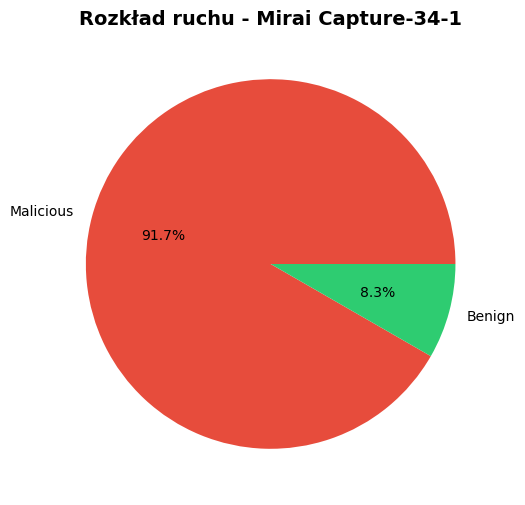

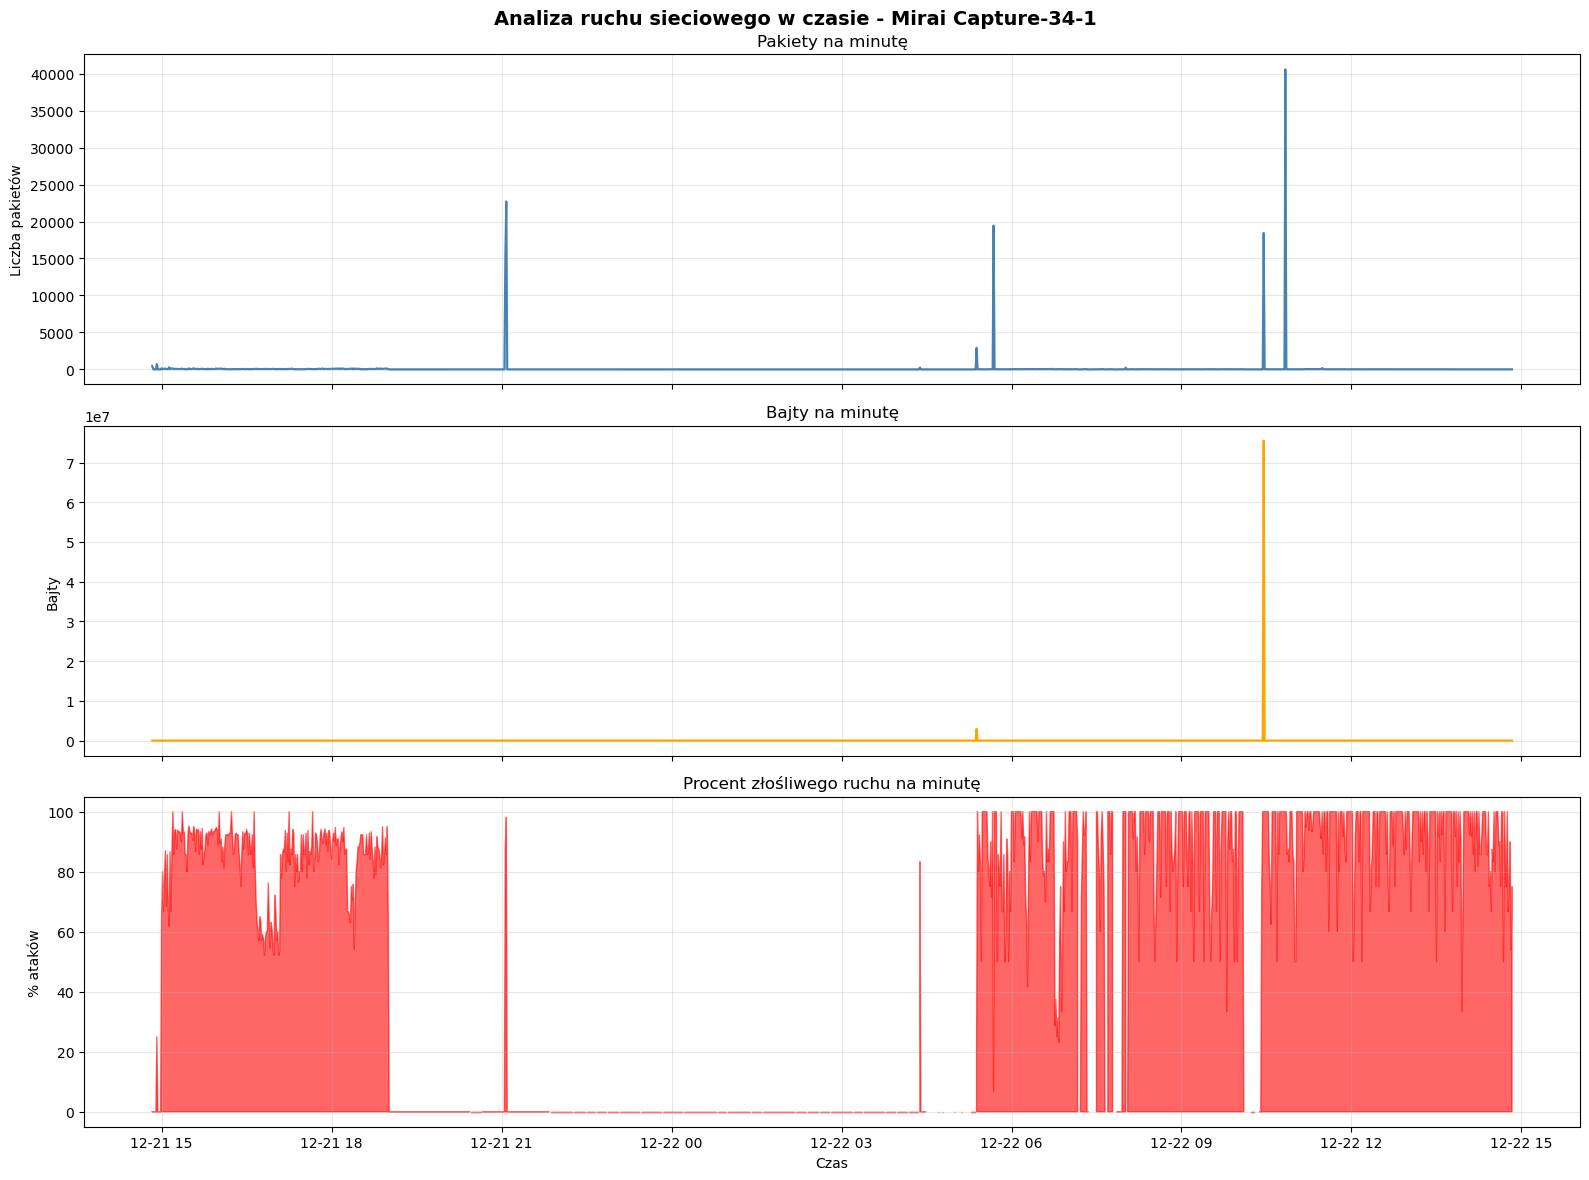

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import entropy as scipy_entropy
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = r"C:\Users\48692\Desktop\Nowy folder (3)\conn.log.labeled.txt"
SCENARIUSZ = "Mirai Capture-34-1"

df = pd.read_csv(FILE_PATH, sep="\t", comment="#", low_memory=False, header=None)

df.columns = ['ts','uid','src_ip','src_port','dst_ip','dst_port',
              'proto','service','duration','orig_bytes','resp_bytes',
              'conn_state','local_orig','local_resp','missed_bytes',
              'history','orig_pkts','orig_ip_bytes','resp_pkts',
              'resp_ip_bytes','tunnel_parents','label','detailed_label']

df['label_num'] = df['label'].apply(lambda x: 0 if 'Benign' in str(x) else 1)
for col in ['duration','orig_bytes','resp_bytes','orig_pkts','resp_pkts']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['ts'] = pd.to_numeric(df['ts'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['ts'], unit='s', errors='coerce')
df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

print(f"Wczytano: {len(df):,} rekordów")
print(f"Benign:    {df[df['label_num']==0].shape[0]:,}")
print(f"Malicious: {df[df['label_num']==1].shape[0]:,}")

etykiety = df['label'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(etykiety, labels=etykiety.index, autopct='%1.1f%%',
        colors=['#e74c3c','#2ecc71'])
plt.title(f'Rozkład ruchu - {SCENARIUSZ}', fontsize=14, fontweight='bold')
plt.show()

df_time = df.set_index('timestamp').resample('1min').agg(
    pakiety=('orig_pkts', 'sum'),
    bajty=('orig_bytes', 'sum'),
    ataki=('label_num', 'sum'),
    wszystkie=('label_num', 'count')
).fillna(0)
df_time['procent_atakow'] = df_time['ataki'] / df_time['wszystkie'].replace(0, np.nan) * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'Analiza ruchu sieciowego w czasie - {SCENARIUSZ}', fontsize=14, fontweight='bold')

axes[0].plot(df_time.index, df_time['pakiety'], color='steelblue', linewidth=1.5)
axes[0].fill_between(df_time.index, df_time['pakiety'], alpha=0.3, color='steelblue')
axes[0].set_ylabel('Liczba pakietów')
axes[0].set_title('Pakiety na minutę')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_time.index, df_time['bajty'], color='orange', linewidth=1.5)
axes[1].fill_between(df_time.index, df_time['bajty'], alpha=0.3, color='orange')
axes[1].set_ylabel('Bajty')
axes[1].set_title('Bajty na minutę')
axes[1].grid(True, alpha=0.3)

axes[2].fill_between(df_time.index, df_time['procent_atakow'], color='red', alpha=0.6)
axes[2].set_ylabel('% ataków')
axes[2].set_title('Procent złośliwego ruchu na minutę')
axes[2].set_xlabel('Czas')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Z-score (próg=3) - wykryto anomalii: 5


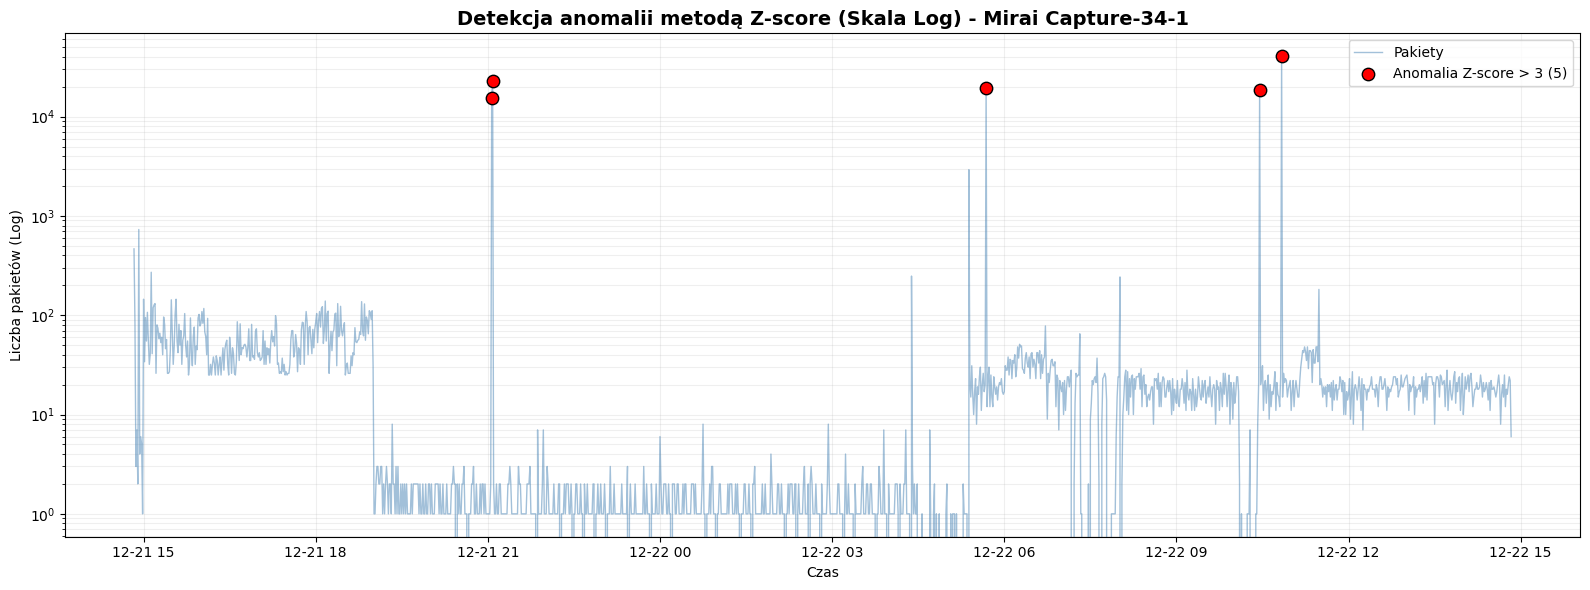

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

z_scores = np.abs(stats.zscore(df_time['pakiety'].fillna(0)))
df_time['z_score'] = z_scores
df_time['z_anomalia'] = z_scores > 3
anomalie_z = df_time[df_time['z_anomalia']]
print(f"Z-score (próg=3) - wykryto anomalii: {len(anomalie_z)}")
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_time.index, df_time['pakiety'], color='steelblue', linewidth=1, alpha=0.5, label='Pakiety')
ax.scatter(anomalie_z.index, anomalie_z['pakiety'],
           color='red', edgecolors='black', zorder=5, s=80, 
           label=f'Anomalia Z-score > 3 ({len(anomalie_z)})')
ax.set_yscale("log")
ax.set_title(f'Detekcja anomalii metodą Z-score (Skala Log) - {SCENARIUSZ}', fontsize=14, fontweight='bold')
ax.set_ylabel('Liczba pakietów (Log)')
ax.set_xlabel('Czas')
ax.legend()
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

IQR - wykryto anomalii: 47


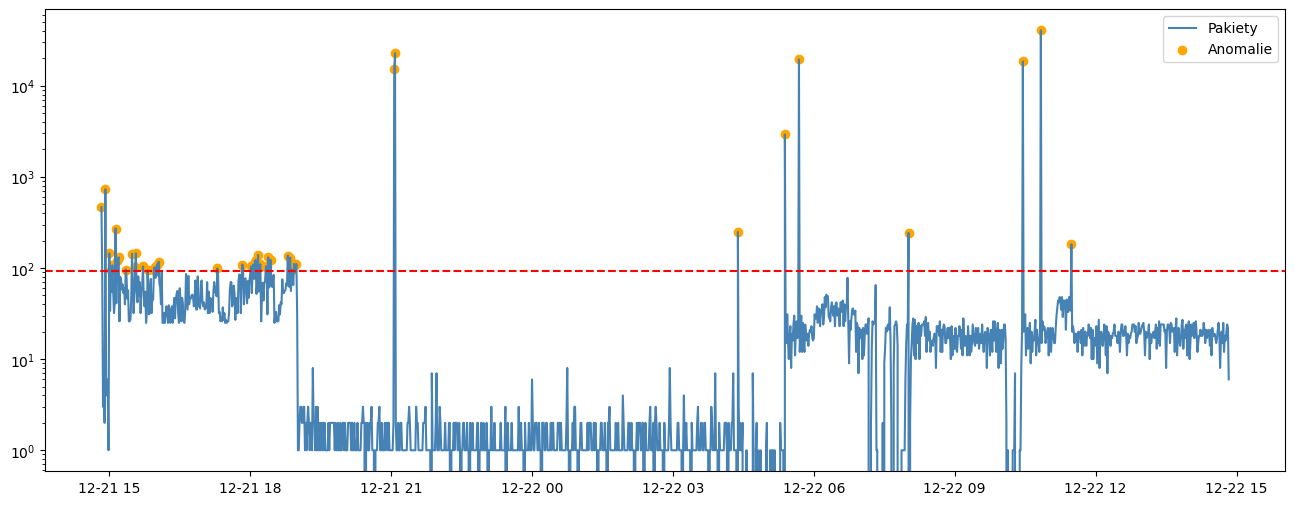

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Q1 = df_time['pakiety'].quantile(0.25)
Q3 = df_time['pakiety'].quantile(0.75)
IQR = Q3 - Q1
prog_gorny = Q3 + 3 * IQR
prog_dolny = Q1 - 3 * IQR
df_time['iqr_anomalia'] = (df_time['pakiety'] > prog_gorny) | (df_time['pakiety'] < prog_dolny)
anomalie_iqr = df_time[df_time['iqr_anomalia']]
print(f"IQR - wykryto anomalii: {len(anomalie_iqr)}")
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_time.index, df_time['pakiety'], color='steelblue', label='Pakiety')
ax.scatter(anomalie_iqr.index, anomalie_iqr['pakiety'], color='orange', label='Anomalie')
ax.axhline(y=prog_gorny, color='red', linestyle='--')
ax.axhline(y=prog_dolny, color='green', linestyle='--')
ax.set_yscale("log")
ax.legend()
plt.show()

Threshold 3σ = 4514.48
Threshold 3σ - wykryto anomalii: 5


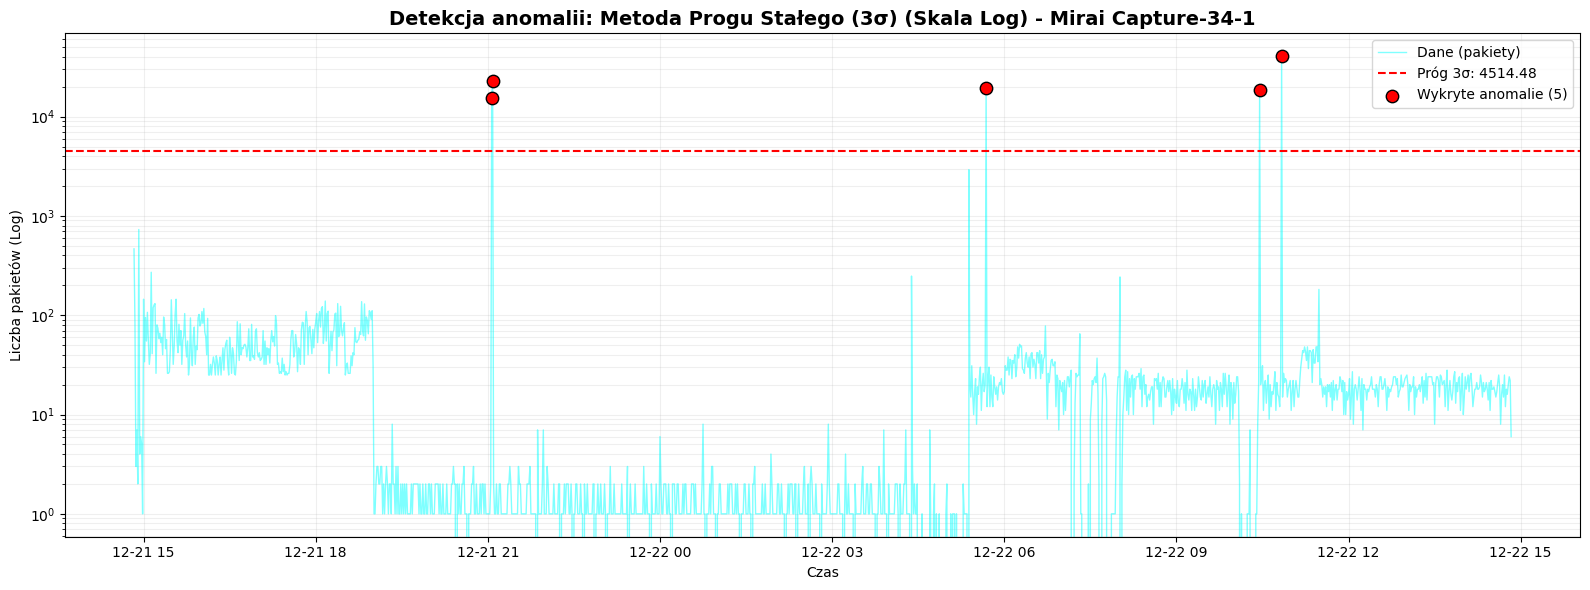

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

srednia = df_time['pakiety'].mean()
odch = df_time['pakiety'].std()
prog_3sigma = srednia + 3 * odch
df_time['prog_anomalia'] = df_time['pakiety'] > prog_3sigma
anomalie_prog = df_time[df_time['prog_anomalia']]
print(f"Threshold 3σ = {prog_3sigma:.2f}")
print(f"Threshold 3σ - wykryto anomalii: {len(anomalie_prog)}")
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_time.index, df_time['pakiety'], color='cyan', linewidth=1, alpha=0.5, label='Dane (pakiety)')
ax.axhline(y=prog_3sigma, color='red', linestyle='--', label=f'Próg 3σ: {prog_3sigma:.2f}')
ax.scatter(anomalie_prog.index, anomalie_prog['pakiety'],
    color='red', edgecolors='black', zorder=5, s=80, label=f'Wykryte anomalie ({len(anomalie_prog)})')
ax.set_yscale("log")
ax.set_title(f'Detekcja anomalii: Metoda Progu Stałego (3σ) (Skala Log) - {SCENARIUSZ}', fontsize=14, fontweight='bold')
ax.set_ylabel('Liczba pakietów (Log)')
ax.set_xlabel('Czas')
ax.legend()
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

Moving Average - wykryto anomalii: 53


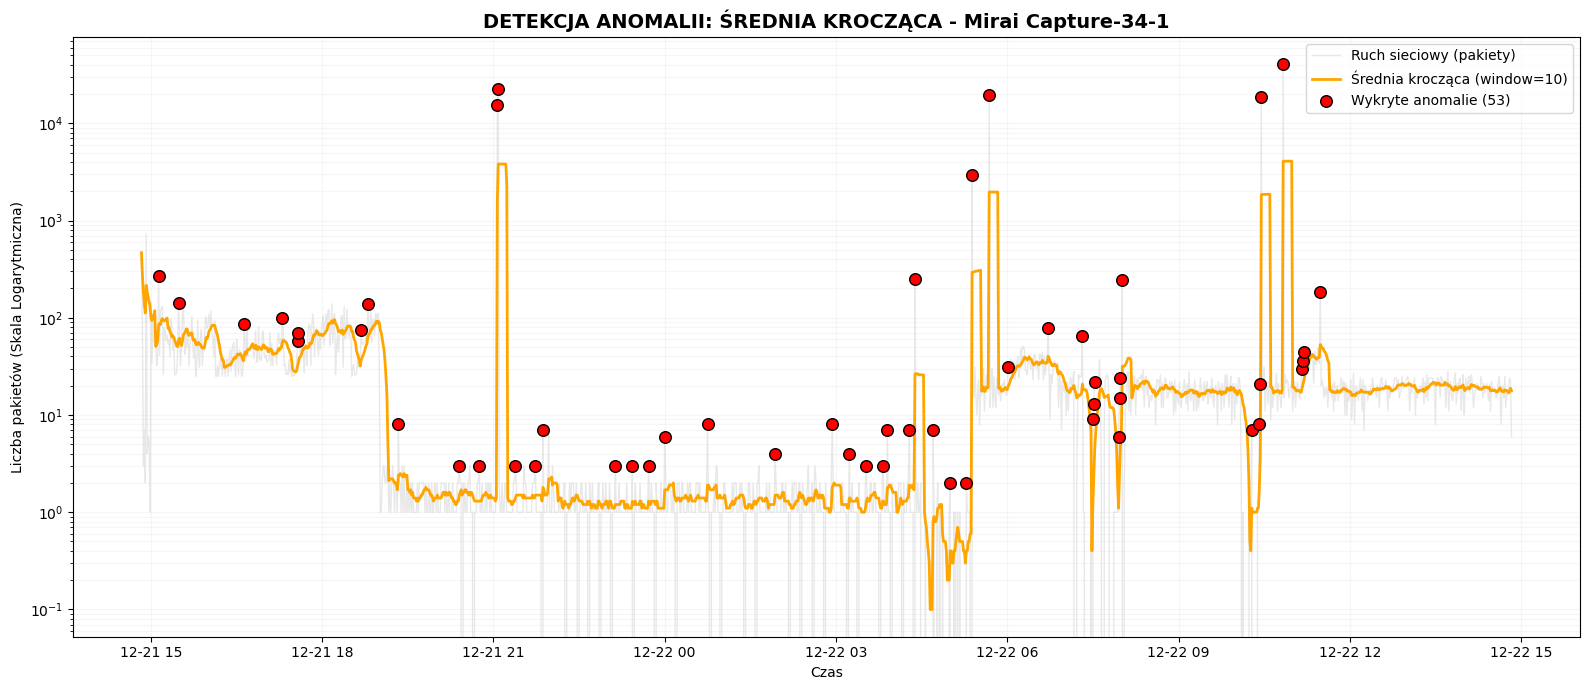

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Parametry metody
okno = 10
mnoznik_std = 2

df_time['MA'] = df_time['pakiety'].rolling(window=okno, min_periods=1).mean()
df_time['MA_std'] = df_time['pakiety'].rolling(window=okno, min_periods=1).std().fillna(0)

df_time['MA_anomalia'] = df_time['pakiety'] > (df_time['MA'] + mnoznik_std * df_time['MA_std'])
anomalie_ma = df_time[df_time['MA_anomalia']]

print(f"Moving Average - wykryto anomalii: {len(anomalie_ma)}")

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(df_time.index, df_time['pakiety'], color='lightgray', linewidth=1, alpha=0.5, label='Ruch sieciowy (pakiety)')

ax.plot(df_time.index, df_time['MA'], color='orange', linewidth=2, label=f'Średnia krocząca (window={okno})')

ax.scatter(anomalie_ma.index, anomalie_ma['pakiety'], color='red', edgecolors='black', s=70, zorder=5, label=f'Wykryte anomalie ({len(anomalie_ma)})')
ax.set_yscale("log")

ax.set_title(f'DETEKCJA ANOMALII: ŚREDNIA KROCZĄCA - {SCENARIUSZ}', fontsize=14, fontweight='bold')
ax.set_ylabel('Liczba pakietów (Skala Logarytmiczna)')
ax.set_xlabel('Czas')
ax.grid(True, which="both", ls="-", alpha=0.1)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Wariancja w czasie (okno=20) - wykryto anomalii: 40


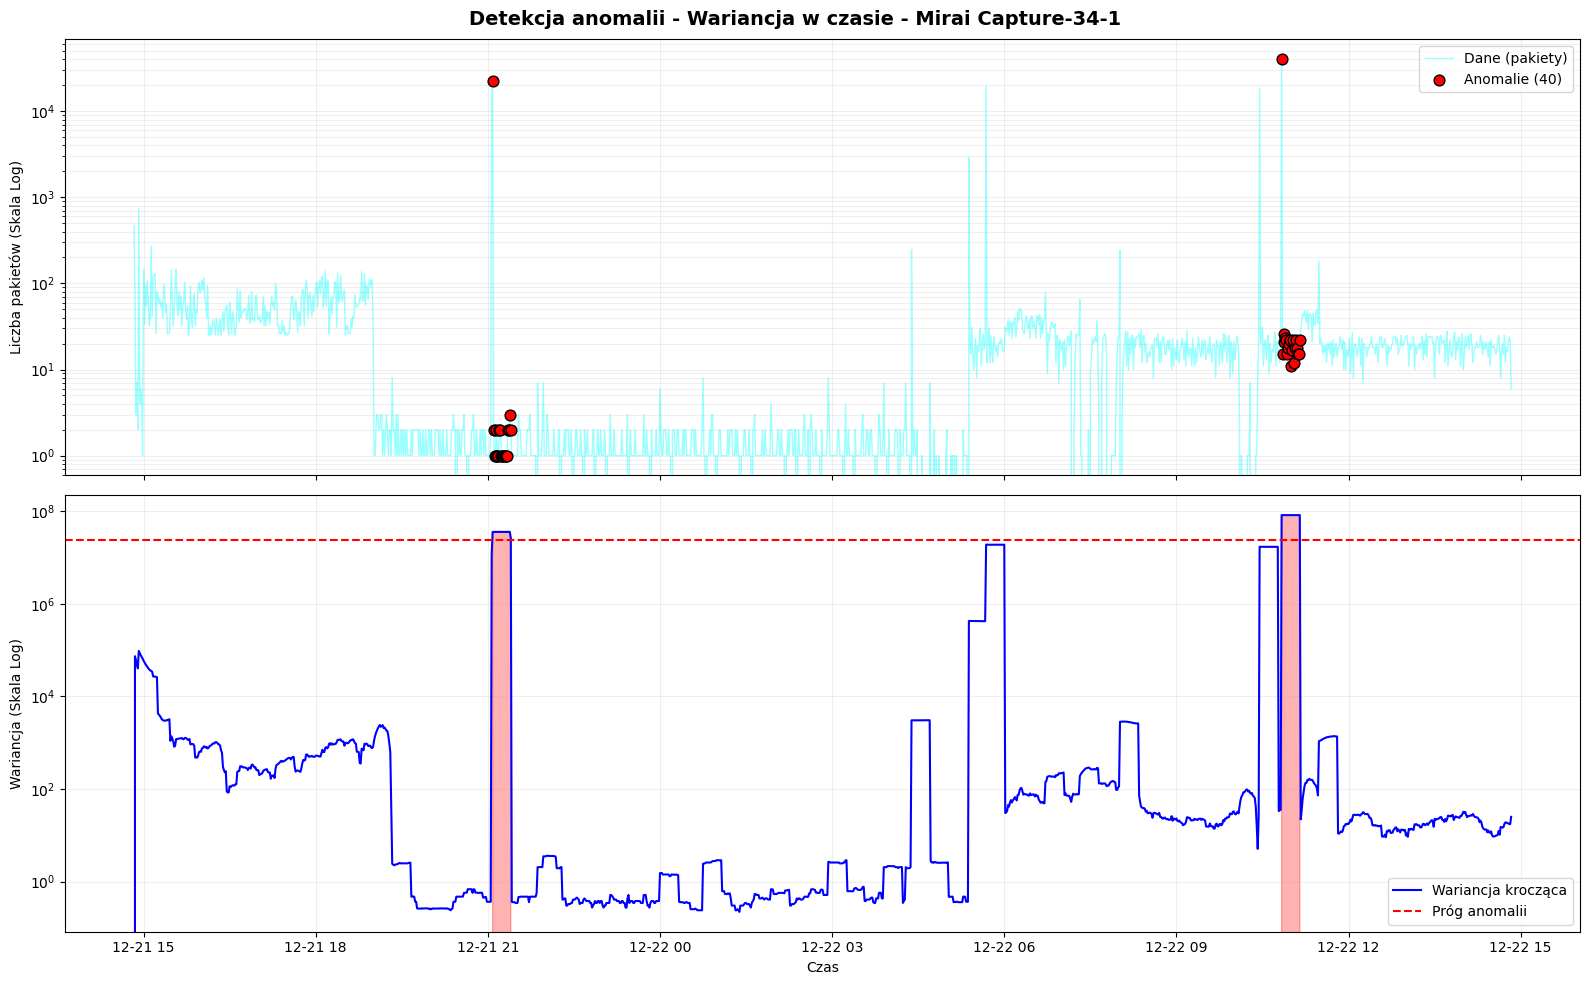

In [6]:
okno_war = 20 
df_time['wariancja'] = df_time['pakiety'].rolling(window=okno_war, min_periods=1).var().fillna(0)
prog_war = df_time['wariancja'].mean() + 2 * df_time['wariancja'].std()
df_time['war_anomalia'] = df_time['wariancja'] > prog_war
anomalie_war = df_time[df_time['war_anomalia']]

print(f"Wariancja w czasie (okno={okno_war}) - wykryto anomalii: {len(anomalie_war)}")

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'Detekcja anomalii - Wariancja w czasie - {SCENARIUSZ}', fontsize=14, fontweight='bold')

axes[0].plot(df_time.index, df_time['pakiety'], color='cyan', linewidth=1, alpha=0.4, label='Dane (pakiety)')
axes[0].scatter(anomalie_war.index, anomalie_war['pakiety'],
                color='red', s=60, edgecolors='black', zorder=5, label=f'Anomalie ({len(anomalie_war)})')
axes[0].set_yscale("log") # Dodane dla czytelności małych skoków
axes[0].set_ylabel('Liczba pakietów (Skala Log)')
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.2)

axes[1].plot(df_time.index, df_time['wariancja'], color='blue', linewidth=1.5, label='Wariancja krocząca')
axes[1].axhline(y=prog_war, color='red', linestyle='--', label='Próg anomalii')
axes[1].fill_between(df_time.index, df_time['wariancja'],
                     where=df_time['war_anomalia'], color='red', alpha=0.3)
axes[1].set_yscale("log") # Wariancja też lepiej wygląda w logarytmie
axes[1].set_ylabel('Wariancja (Skala Log)')
axes[1].set_xlabel('Czas')
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

Skośność globalna: 20.7385
Kurtoza Pearsona: 483.9747


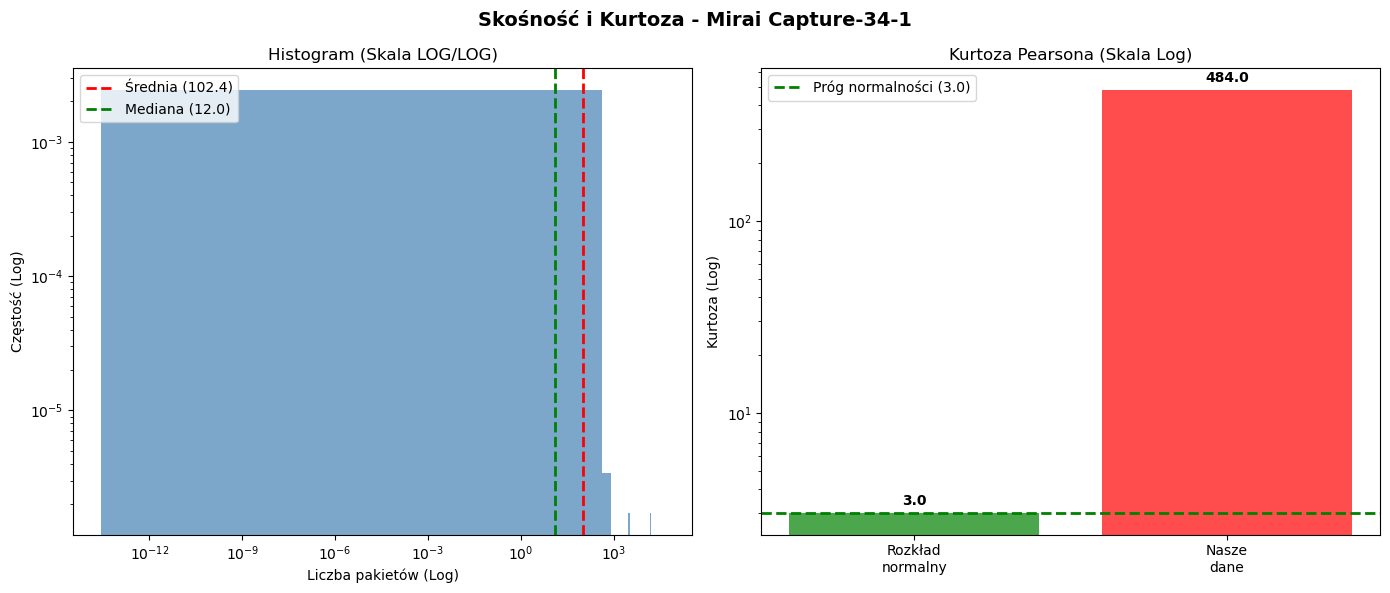

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

skosnosc = skew(df_time['pakiety'])
kurt = kurtosis(df_time['pakiety'], fisher=False)
srednia = df_time['pakiety'].mean()
mediana = df_time['pakiety'].median()

print(f"Skośność globalna: {skosnosc:.4f}")
print(f"Kurtoza Pearsona: {kurt:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Skośność i Kurtoza - {SCENARIUSZ}', fontsize=14, fontweight='bold')

axes[0].hist(df_time['pakiety'], bins=100, color='steelblue', alpha=0.7, density=True)
axes[0].axvline(x=srednia, color='red', linestyle='--', linewidth=2, label=f'Średnia ({srednia:.1f})')
axes[0].axvline(x=mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana ({mediana:.1f})')
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_title(f'Histogram (Skala LOG/LOG)')
axes[0].set_xlabel('Liczba pakietów (Log)')
axes[0].set_ylabel('Częstość (Log)')
axes[0].legend()

axes[1].bar(['Rozkład\nnormalny', 'Nasze\ndane'], [3.0, kurt], color=['green', 'red'], alpha=0.7)
axes[1].axhline(y=3.0, color='green', linestyle='--', linewidth=2, label='Próg normalności (3.0)')
axes[1].set_yscale('log')
axes[1].set_title('Kurtoza Pearsona (Skala Log)')
axes[1].set_ylabel('Kurtoza (Log)')
axes[1].legend()

for i, v in enumerate([3.0, kurt]): axes[1].text(i, v * 1.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Entropia: 0.0649 bitów
Entropia maksymalna (100 binów): 6.6439 bitów
Entropia znormalizowana: 0.0098 (1.0%)


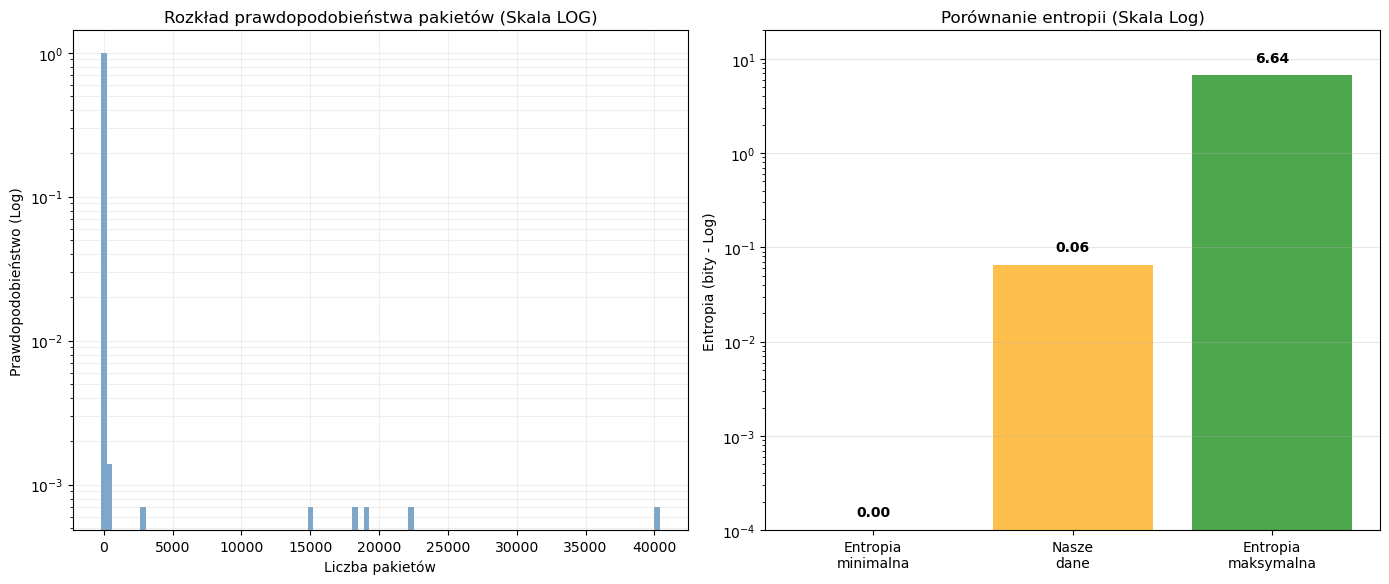

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy

counts, _ = np.histogram(df_time['pakiety'], bins=100)
counts = counts[counts > 0]
probs = counts / counts.sum()
entropia = scipy_entropy(probs, base=2)
entropia_max = np.log2(100)
entropia_norm = entropia / entropia_max

print(f"Entropia: {entropia:.4f} bitów")
print(f"Entropia maksymalna (100 binów): {entropia_max:.4f} bitów")
print(f"Entropia znormalizowana: {entropia_norm:.4f} ({entropia_norm*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

counts_all, bins = np.histogram(df_time['pakiety'], bins=100)
probs_all = counts_all / counts_all.sum()
axes[0].bar(bins[:-1], probs_all, width=np.diff(bins), color='steelblue', alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_title('Rozkład prawdopodobieństwa pakietów (Skala LOG)')
axes[0].set_xlabel('Liczba pakietów')
axes[0].set_ylabel('Prawdopodobieństwo (Log)')
axes[0].grid(True, which="both", alpha=0.2)

bars = axes[1].bar(['Entropia\nminimalna', 'Nasze\ndane', 'Entropia\nmaksymalna'],[0.0001, entropia if entropia > 0 else 0.0001, entropia_max],
                   color=['blue', 'orange', 'green'], alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_ylim(0.0001, 20) 
axes[1].set_title('Porównanie entropii (Skala Log)')
axes[1].set_ylabel('Entropia (bity - Log)')
axes[1].grid(True, which="major", axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    val = height if height > 0.001 else 0.0
    axes[1].text(bar.get_x() + bar.get_width()/2., height * 1.3, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

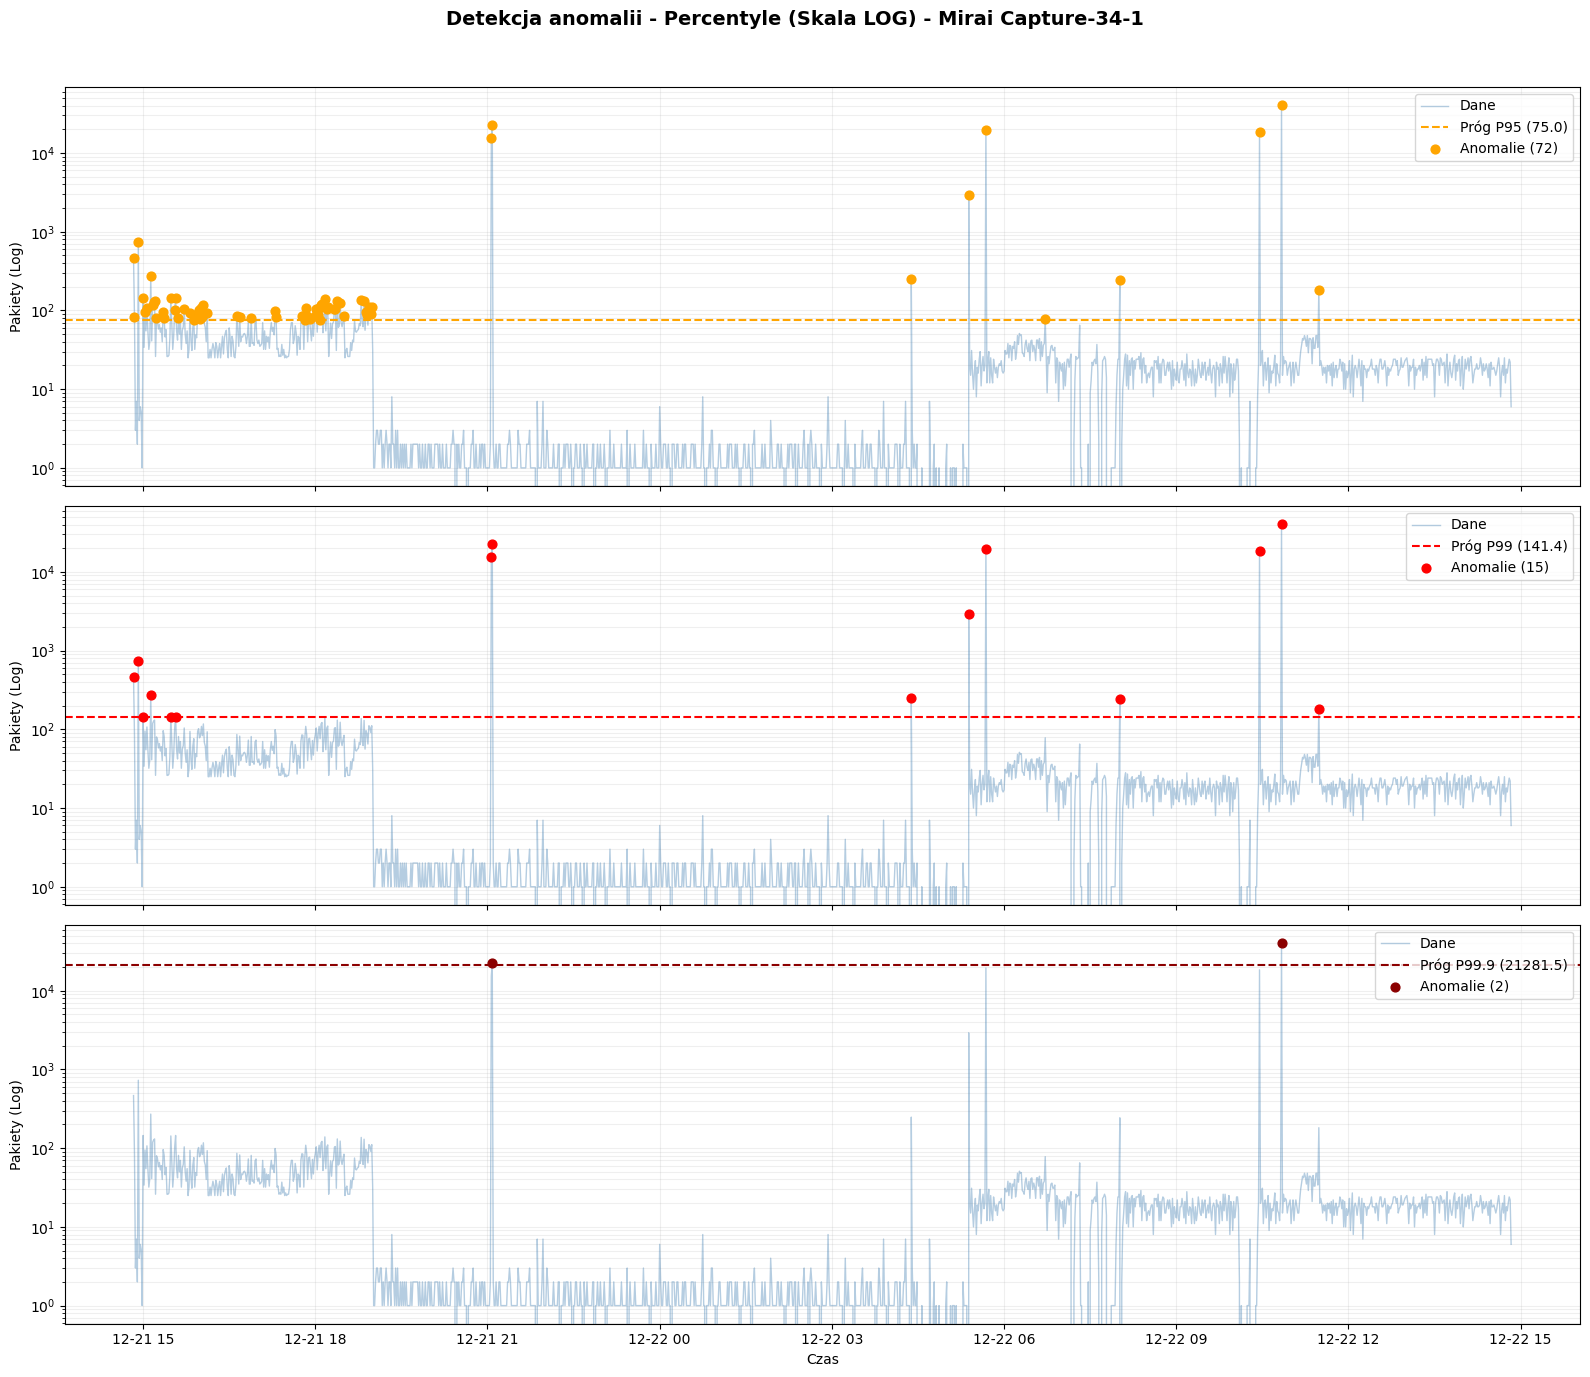


========== PORÓWNANIE PERCENTYLI ==========
P95   - próg: 75.00 | anomalie: 72
P99   - próg: 141.40 | anomalie: 15
P99.9 - próg: 21281.48 | anomalie: 2


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

p95 = df_time['pakiety'].quantile(0.95)
p99 = df_time['pakiety'].quantile(0.99)
p999 = df_time['pakiety'].quantile(0.999)

an_p95 = df_time[df_time['pakiety'] > p95]
an_p99 = df_time[df_time['pakiety'] > p99]
an_p999 = df_time[df_time['pakiety'] > p999]

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle(f'Detekcja anomalii - Percentyle (Skala LOG) - {SCENARIUSZ}', fontsize=14, fontweight='bold')

for ax, (prog, anomalie, label, kolor) in zip(axes, [
    (p95, an_p95, 'P95', 'orange'),
    (p99, an_p99, 'P99', 'red'),
    (p999, an_p999, 'P99.9', 'darkred')
]):
    ax.plot(df_time.index, df_time['pakiety'], color='steelblue', linewidth=1, alpha=0.4, label='Dane')
    ax.axhline(y=prog, color=kolor, linestyle='--', label=f'Próg {label} ({prog:.1f})')
    ax.scatter(anomalie.index, anomalie['pakiety'], color=kolor, s=40, zorder=5, label=f'Anomalie ({len(anomalie)})')
    
    ax.set_yscale('log')
    ax.set_ylabel('Pakiety (Log)')
    ax.legend(loc='upper right')
    ax.grid(True, which="both", alpha=0.2)

axes[-1].set_xlabel('Czas')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\n========== PORÓWNANIE PERCENTYLI ==========")
print(f"P95   - próg: {p95:.2f} | anomalie: {len(an_p95)}")
print(f"P99   - próg: {p99:.2f} | anomalie: {len(an_p99)}")
print(f"P99.9 - próg: {p999:.2f} | anomalie: {len(an_p999)}")

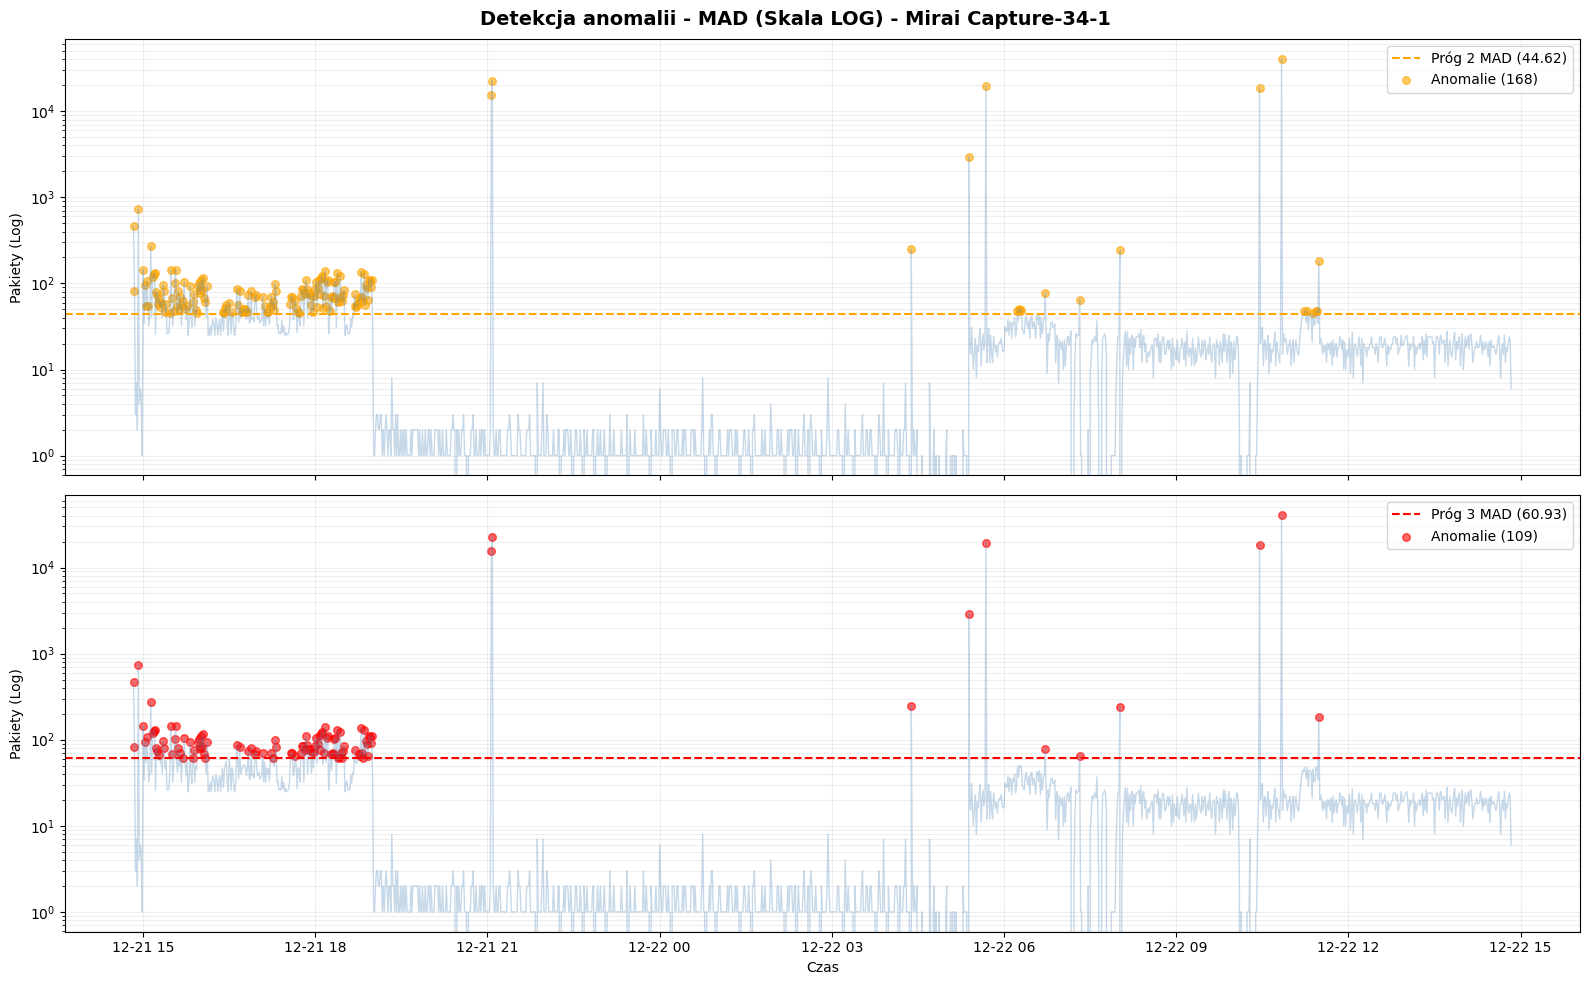

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mediana = df_time['pakiety'].median()
MAD = (df_time['pakiety'] - mediana).abs().median()
MAD_skalowany = MAD * 1.4826

mad_div = MAD_skalowany if MAD_skalowany > 0 else 1
df_time['mad_score'] = (df_time['pakiety'] - mediana).abs() / mad_div

an_mad2 = df_time[df_time['mad_score'] > 2]
an_mad3 = df_time[df_time['mad_score'] > 3]

prog_mad2 = mediana + 2 * MAD_skalowany
prog_mad3 = mediana + 3 * MAD_skalowany

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'Detekcja anomalii - MAD (Skala LOG) - {SCENARIUSZ}', fontsize=14, fontweight='bold')

for ax, (prog, anomalie, label, kolor) in zip(axes, [
    (prog_mad2, an_mad2, 'Próg 2 MAD', 'orange'),
    (prog_mad3, an_mad3, 'Próg 3 MAD', 'red')
]):
    ax.plot(df_time.index, df_time['pakiety'], color='steelblue', linewidth=1, alpha=0.3)
    ax.axhline(y=prog if prog > 0 else 0.1, color=kolor, linestyle='--', label=f'{label} ({prog:.2f})')
    ax.scatter(anomalie.index, anomalie['pakiety'], color=kolor, s=30, alpha=0.6, label=f'Anomalie ({len(anomalie)})')
    
    ax.set_yscale('log')
    ax.set_ylabel('Pakiety (Log)')
    ax.legend(loc='upper right')
    ax.grid(True, which="both", alpha=0.2)

axes[-1].set_xlabel('Czas')
plt.tight_layout()
plt.show()

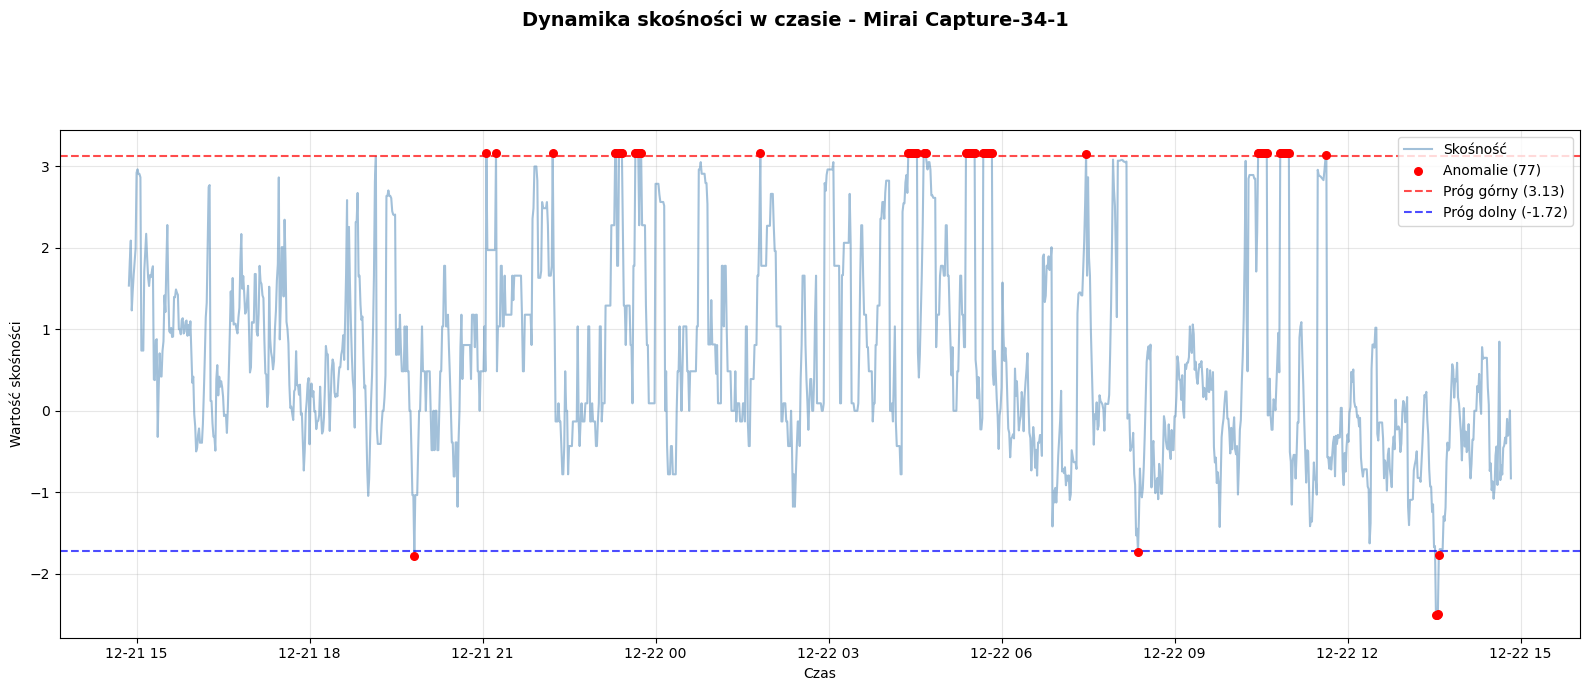

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Obliczenia
okno_skosnosc = 10
df_time['skosnosc'] = df_time['pakiety'].rolling(window=okno_skosnosc, min_periods=3).skew()

mean_skos = df_time['skosnosc'].mean()
std_skos = df_time['skosnosc'].std()
prog_skos_g = mean_skos + 2 * std_skos
prog_skos_d = mean_skos - 2 * std_skos
an_skos = df_time[(df_time['skosnosc'] > prog_skos_g) | (df_time['skosnosc'] < prog_skos_d)]

# Jeden wykres
fig, ax = plt.subplots(figsize=(16, 7))

fig.suptitle(f'Dynamika skośności w czasie - {SCENARIUSZ}', fontsize=14, fontweight='bold')

# Wykres skośności
ax.plot(df_time.index, df_time['skosnosc'], color='steelblue', alpha=0.5, label='Skośność')
ax.scatter(an_skos.index, an_skos['skosnosc'], color='red', s=30, zorder=5, label=f'Anomalie ({len(an_skos)})')

ax.axhline(y=prog_skos_g, color='red', linestyle='--', alpha=0.7, label=f'Próg górny ({prog_skos_g:.2f})')
ax.axhline(y=prog_skos_d, color='blue', linestyle='--', alpha=0.7, label=f'Próg dolny ({prog_skos_d:.2f})')

ax.set_ylabel('Wartość skośności')
ax.set_xlabel('Czas')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

TCP na sekundę: Średnia=14.80, Max=9909
Próg IQR: 22.50 | Anomalie: 7
Próg 3σ: 870.21 | Anomalie: 2

UDP na sekundę: Średnia=1.26, Max=13
Próg IQR: 5.00 | Anomalie: 39
Próg 3σ: 5.89 | Anomalie: 39


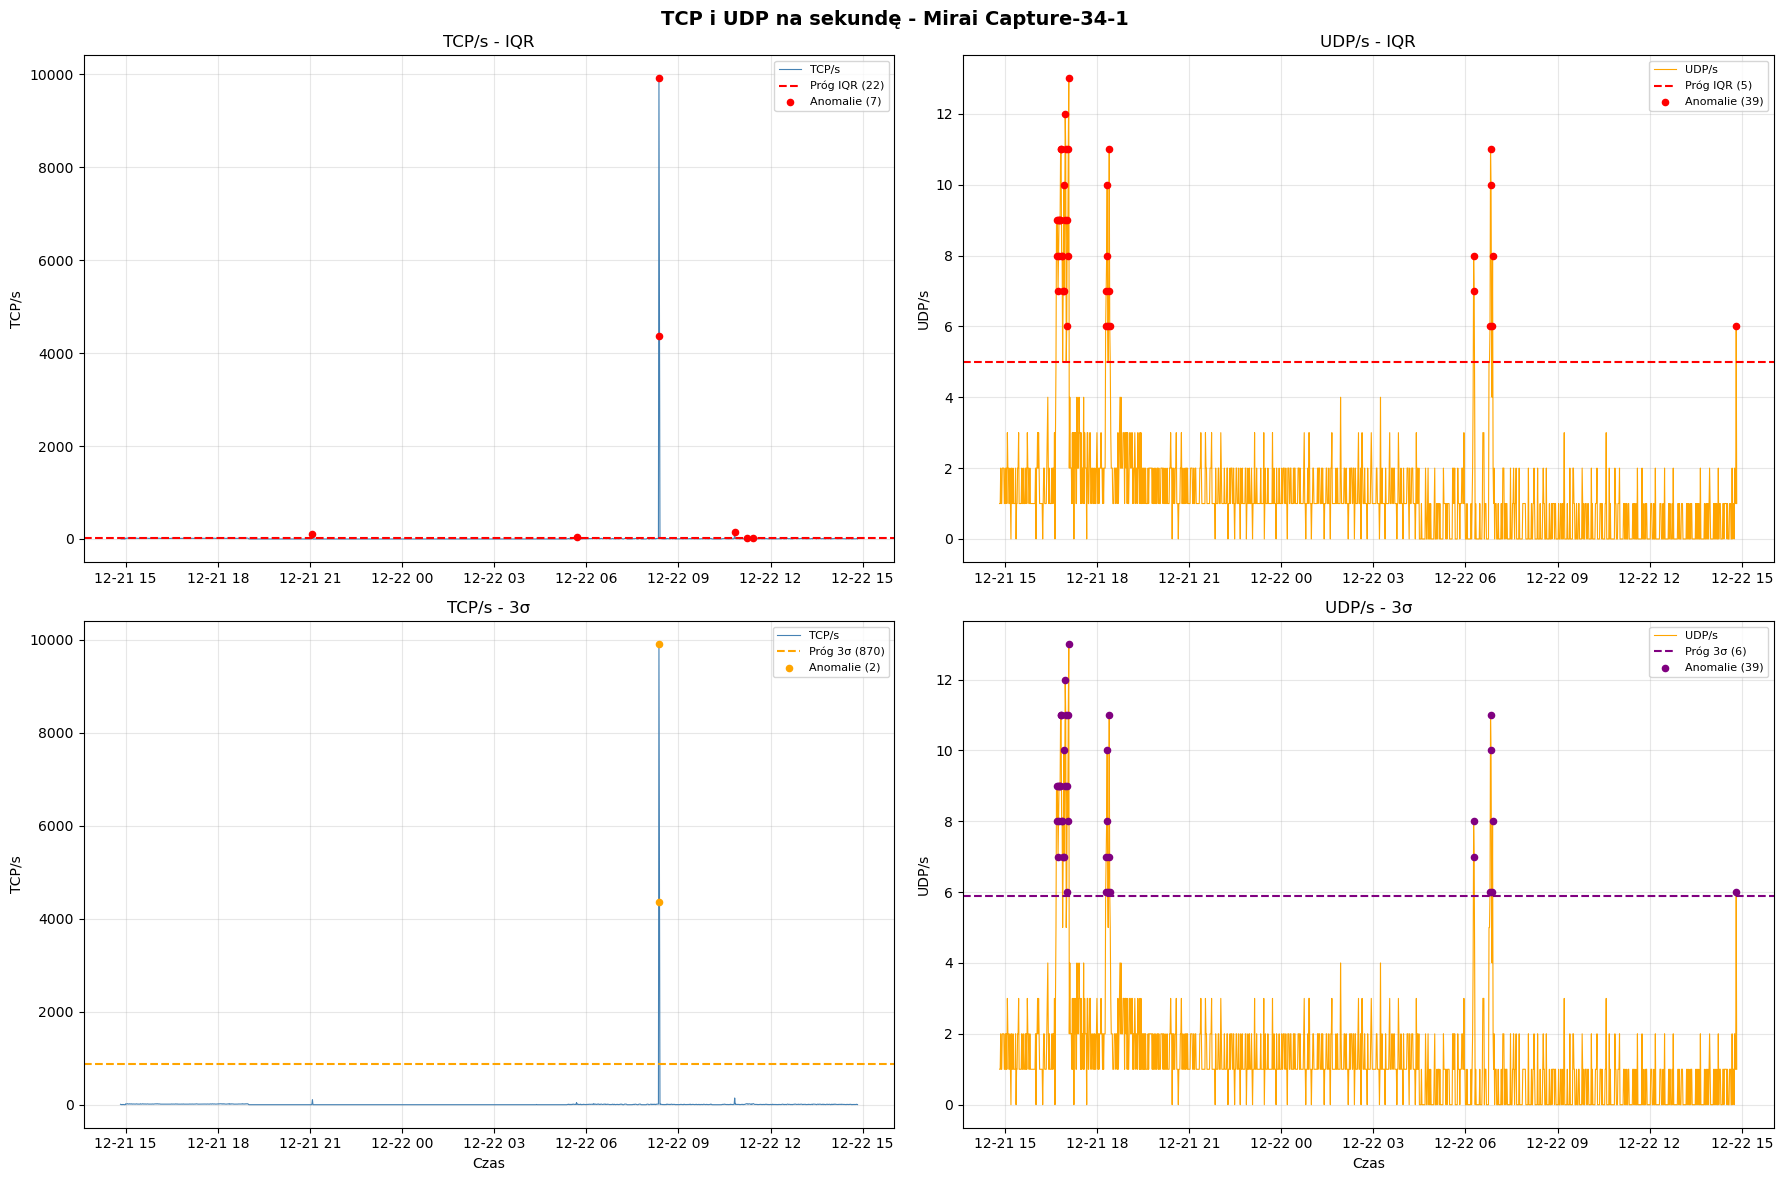

In [12]:
# ============================================================
# METODA 11: TCP i UDP na sekundę
# ============================================================

df_tcp = df[df['proto'] == 'tcp'].set_index('timestamp').resample('1min').size()
df_udp = df[df['proto'] == 'udp'].set_index('timestamp').resample('1min').size()

tcp_mean = df_tcp.mean()
tcp_std = df_tcp.std()
tcp_iqr_q1 = df_tcp.quantile(0.25)
tcp_iqr_q3 = df_tcp.quantile(0.75)
tcp_iqr = tcp_iqr_q3 - tcp_iqr_q1
tcp_prog_iqr = tcp_iqr_q3 + 1.5 * tcp_iqr
tcp_prog_3s = tcp_mean + 3 * tcp_std
tcp_an_iqr = df_tcp[df_tcp > tcp_prog_iqr]
tcp_an_3s = df_tcp[df_tcp > tcp_prog_3s]

udp_mean = df_udp.mean()
udp_std = df_udp.std()
udp_iqr_q1 = df_udp.quantile(0.25)
udp_iqr_q3 = df_udp.quantile(0.75)
udp_iqr = udp_iqr_q3 - udp_iqr_q1
udp_prog_iqr = udp_iqr_q3 + 1.5 * udp_iqr
udp_prog_3s = udp_mean + 3 * udp_std
udp_an_iqr = df_udp[df_udp > udp_prog_iqr]
udp_an_3s = df_udp[df_udp > udp_prog_3s]

print(f"TCP na sekundę: Średnia={tcp_mean:.2f}, Max={df_tcp.max()}")
print(f"Próg IQR: {tcp_prog_iqr:.2f} | Anomalie: {len(tcp_an_iqr)}")
print(f"Próg 3σ: {tcp_prog_3s:.2f} | Anomalie: {len(tcp_an_3s)}")
print(f"\nUDP na sekundę: Średnia={udp_mean:.2f}, Max={df_udp.max()}")
print(f"Próg IQR: {udp_prog_iqr:.2f} | Anomalie: {len(udp_an_iqr)}")
print(f"Próg 3σ: {udp_prog_3s:.2f} | Anomalie: {len(udp_an_3s)}")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'TCP i UDP na sekundę - {SCENARIUSZ}', fontsize=14, fontweight='bold')

axes[0,0].plot(df_tcp.index, df_tcp.values, color='steelblue', linewidth=0.8, label='TCP/s')
axes[0,0].axhline(y=tcp_prog_iqr, color='red', linestyle='--', label=f'Próg IQR ({tcp_prog_iqr:.0f})')
axes[0,0].scatter(tcp_an_iqr.index, tcp_an_iqr.values, color='red', s=20, zorder=5, label=f'Anomalie ({len(tcp_an_iqr)})')
axes[0,0].set_title('TCP/s - IQR')
axes[0,0].set_ylabel('TCP/s')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

axes[1,0].plot(df_tcp.index, df_tcp.values, color='steelblue', linewidth=0.8, label='TCP/s')
axes[1,0].axhline(y=tcp_prog_3s, color='orange', linestyle='--', label=f'Próg 3σ ({tcp_prog_3s:.0f})')
axes[1,0].scatter(tcp_an_3s.index, tcp_an_3s.values, color='orange', s=20, zorder=5, label=f'Anomalie ({len(tcp_an_3s)})')
axes[1,0].set_title('TCP/s - 3σ')
axes[1,0].set_ylabel('TCP/s')
axes[1,0].set_xlabel('Czas')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

axes[0,1].plot(df_udp.index, df_udp.values, color='orange', linewidth=0.8, label='UDP/s')
axes[0,1].axhline(y=udp_prog_iqr, color='red', linestyle='--', label=f'Próg IQR ({udp_prog_iqr:.0f})')
axes[0,1].scatter(udp_an_iqr.index, udp_an_iqr.values, color='red', s=20, zorder=5, label=f'Anomalie ({len(udp_an_iqr)})')
axes[0,1].set_title('UDP/s - IQR')
axes[0,1].set_ylabel('UDP/s')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

axes[1,1].plot(df_udp.index, df_udp.values, color='orange', linewidth=0.8, label='UDP/s')
axes[1,1].axhline(y=udp_prog_3s, color='purple', linestyle='--', label=f'Próg 3σ ({udp_prog_3s:.0f})')
axes[1,1].scatter(udp_an_3s.index, udp_an_3s.values, color='purple', s=20, zorder=5, label=f'Anomalie ({len(udp_an_3s)})')
axes[1,1].set_title('UDP/s - 3σ')
axes[1,1].set_ylabel('UDP/s')
axes[1,1].set_xlabel('Czas')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
ataki_df = df[df['label_num'] == 1].copy()
minuty_z_atakami = set(ataki_df['timestamp'].dt.floor('min'))

print(f"Liczba minut zawierających atak: {len(minuty_z_atakami)}")

metody_eval = [
    ('Z-score', anomalie_z),
    ('IQR', anomalie_iqr),
    ('3σ', anomalie_prog),
    ('MA', anomalie_ma),
    ('Wariancja', anomalie_war),
    ('P95', an_p95),
    ('MAD(2)', an_mad2),
]

print("\n" + "="*70)
print("OCENA METOD - POPRAWNE LICZENIE")
print("="*70)
print(f"{'Metoda':<12} {'Anomalie':<10} {'TP':<8} {'FP':<8} {'Czułość':<10} {'FPR':<10}")
print("-"*70)

for nazwa, anomalie_df in metody_eval:
    anomalie_minuty = set(anomalie_df.index.floor('min'))
    tp = len(anomalie_minuty & minuty_z_atakami)
    fp = len(anomalie_minuty - minuty_z_atakami)
    fn = len(minuty_z_atakami - anomalie_minuty)
    czulosc = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    wszystkie_minuty_bez_ataku = len(df['timestamp'].dt.floor('min').unique()) - len(minuty_z_atakami)
    fpr = (fp / wszystkie_minuty_bez_ataku * 100) if wszystkie_minuty_bez_ataku > 0 else 0
    print(f"{nazwa:<12} {len(anomalie_df):<10} {tp:<8} {fp:<8} {czulosc:6.1f}%   {fpr:6.1f}%")

Liczba minut zawierających atak: 766

OCENA METOD - POPRAWNE LICZENIE
Metoda       Anomalie   TP       FP       Czułość    FPR       
----------------------------------------------------------------------
Z-score      5          5        0           0.7%      0.0%
IQR          47         46       1           6.0%      0.2%
3σ           5          5        0           0.7%      0.0%
MA           53         30       23          3.9%      3.9%
Wariancja    40         21       19          2.7%      3.2%
P95          72         70       2           9.1%      0.3%
MAD(2)       168        166      2          21.7%      0.3%
